# Detección de Fraude en Transacciones Financieras

Este notebook entrena un modelo de clasificación para identificar transacciones fraudulentas en un dataset de operaciones financieras sintéticas.

**Estructura del notebook:**
1. Importaciones y carga de datos
2. Análisis exploratorio (EDA)
3. Preprocesamiento y modelado
4. Evaluación y exportación del modelo

## 1. Importaciones y carga de datos

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

In [2]:
warnings.filterwarnings("ignore")

Cargamos el dataset desde el fichero CSV. Contiene transacciones financieras sintéticas con información sobre el tipo de operación, importes y saldos de emisor y receptor.

In [3]:
df = pd.read_csv('data/AIML Dataset.csv')

In [4]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


## 2. Análisis Exploratorio (EDA)

### 2.1 Estructura y distribución de la variable objetivo

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Analizamos el desbalance de clases. La variable objetivo  indica si la transacción es fraudulenta (1) o legítima (0).

In [7]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
round((df['isFraud'].value_counts()[1] / df.shape[0]) * 100, 2)

0.13

El dataframe tiene 8213 casos de fraude (0'13%) y 6354407 casos que no son fraude. Las clases están desbalanceadas

Comprobamos si hay valores nulos en el dataset.

In [9]:
df.isnull().sum().sum()

0

### 2.2 Distribución por tipo de transacción

Visualizamos cuántas transacciones hay de cada tipo y cuál es la tasa de fraude en cada categoría.

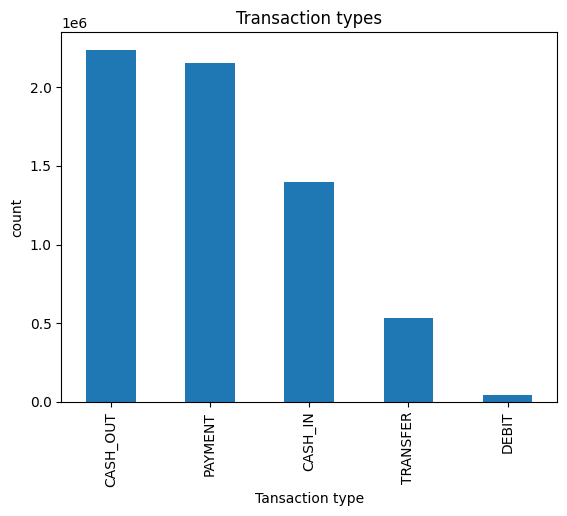

In [10]:
df['type'].value_counts().plot(kind="bar", title="Transaction types")
plt.xlabel("Tansaction type")
plt.ylabel("count")
plt.show()

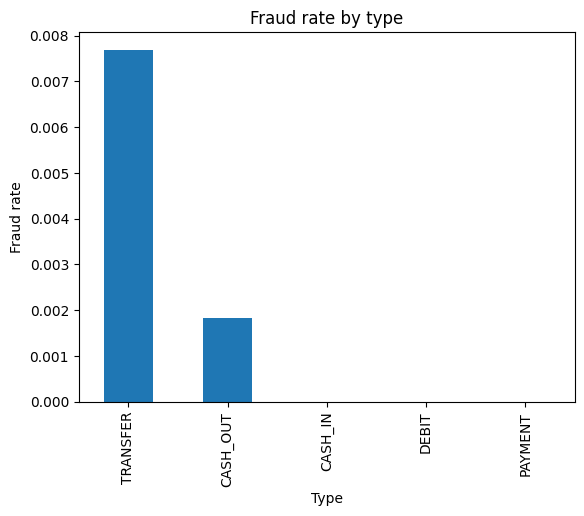

In [11]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud rate by type")
plt.xlabel("Type")
plt.ylabel("Fraud rate")
plt.show()

### 2.3 Análisis del importe

Exploramos la distribución del importe de las transacciones. Dado el amplio rango de valores, utilizamos escala logarítmica para visualizarlo mejor. También comparamos el importe entre transacciones fraudulentas y legítimas.

In [12]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

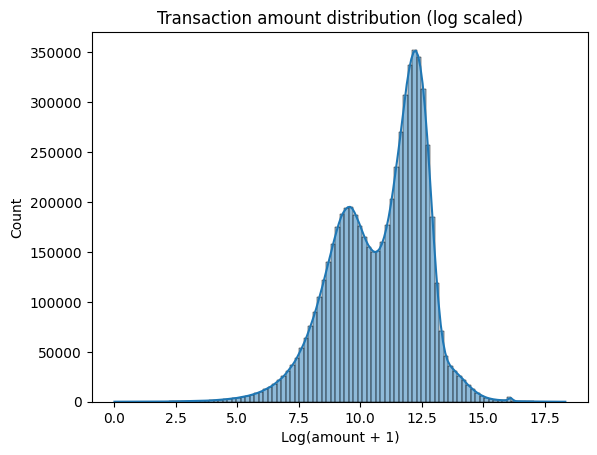

In [13]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True)
plt.title("Transaction amount distribution (log scaled)")
plt.xlabel("Log(amount + 1)")
plt.show()

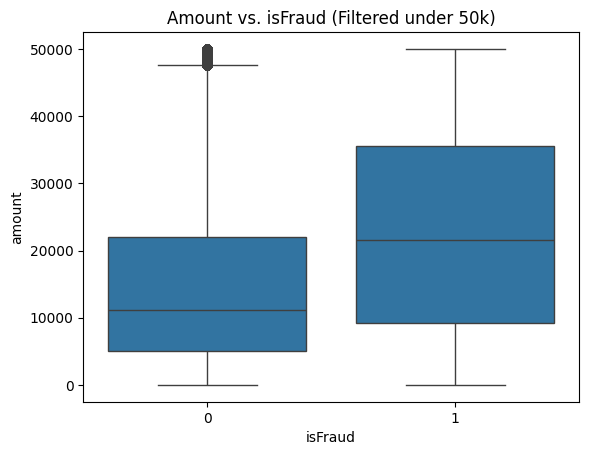

In [14]:
sns.boxplot(data=df[df["amount"] < 50000], x="isFraud", y="amount")
plt.title("Amount vs. isFraud (Filtered under 50k)")
plt.show()

### 2.4 Análisis de diferencias de saldo

Calculamos la diferencia entre el saldo antes y después de la transacción tanto para el emisor como para el receptor. Diferencias negativas (el saldo sube tras una salida de dinero) pueden indicar inconsistencias o comportamiento anómalo.

In [15]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [16]:
(df["balanceDiffOrig"] < 0).sum()

1399253

In [17]:
(df["balanceDiffDest"] < 0).sum()

1238864

### 2.5 Evolución temporal del fraude

Analizamos cómo se distribuye el fraude a lo largo del tiempo (variable ). Una vez analizada, la descartamos como feature ya que no aporta información generalizable al modelo.

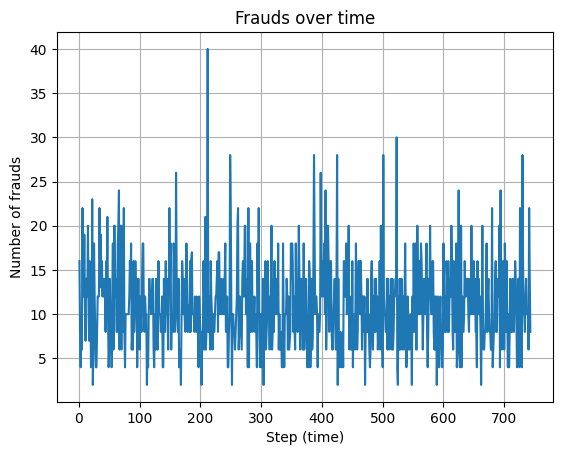

In [18]:
fraud_by_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(fraud_by_step.index, fraud_by_step.values, label="Frauds per step")
plt.xlabel("Step (time)")
plt.ylabel("Number of frauds")
plt.title("Frauds over time")
plt.grid(True)
plt.show()

In [19]:
df.drop(columns="step", inplace=True)

### 2.6 Análisis de emisores y receptores

Exploramos los identificadores de cuenta. Como cada cuenta aparece pocas veces (el dataset es sintético), estos campos no son útiles como features y serán eliminados.

In [20]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [21]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [22]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

### 2.7 Fraude en TRANSFER y CASH_OUT

El fraude se concentra exclusivamente en los tipos TRANSFER y CASH_OUT. Lo visualizamos para confirmar este patrón.

In [23]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
fraud_types.value_counts()

type      amount       nameOrig     oldbalanceOrg  newbalanceOrig  nameDest     oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  balanceDiffOrig  balanceDiffDest
CASH_OUT  0.00         C10965156    0.0            0.0             C1493336195  230289.66       230289.66       1        0               0.0              0.00               1
          291492.38    C476424797   20636.0        0.0             C1415106678  312009.02       603501.40       0        0               20636.0          291492.38          1
          291489.96    C1530475857  41017.0        0.0             C890272476   96257.88        387747.84       0        0               41017.0          291489.96          1
          291490.47    C1742252465  7562.0         0.0             C2109085857  3843376.83      4134867.30      0        0               7562.0           291490.47          1
          291490.53    C1849913375  10726.0        0.0             C1002276505  0.00            291490.53       0        0        

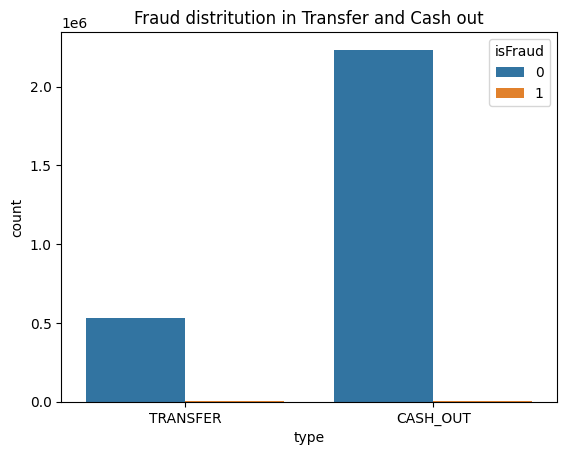

In [24]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud distritution in Transfer and Cash out")
plt.show()

### 2.8 Matriz de correlación

Analizamos la correlación entre las variables numéricas y la variable objetivo. Esto nos ayuda a entender qué features tienen más relación lineal con el fraude.

In [25]:
corr = df[["amount","oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [26]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


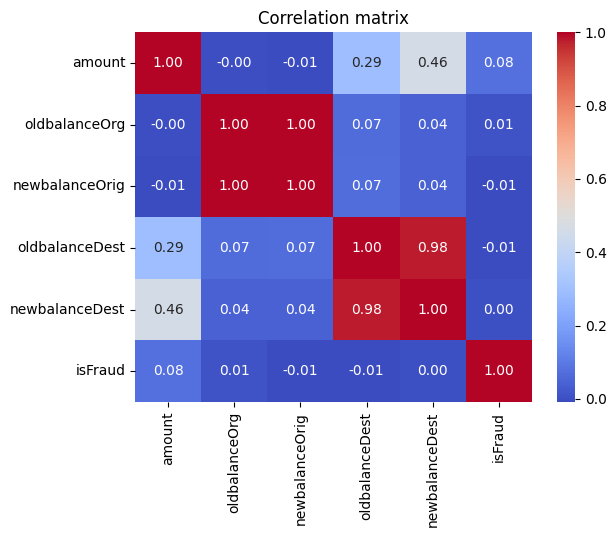

In [27]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

### 2.9 Patrón de saldo cero tras la transacción

Un patrón frecuente en el fraude es que el saldo del emisor queda a cero después de la operación. Cuantificamos cuántas transacciones presentan este comportamiento.

In [28]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [29]:
len(zero_after_transfer)

1188074

## 3. Preprocesamiento y Modelado

### 3.1 Selección de features

Eliminamos las columnas que no aportan valor predictivo: los identificadores de cuenta (nameOrig, nameDest) y el flag automático del sistema (isFlaggedFraud), que tiene muy baja cobertura.

In [30]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [31]:
df_model = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis= 1)

In [32]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


Definimos las features numéricas y categóricas, y separamos la variable objetivo .

In [33]:
categorical = ['type']
numeric =  ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
y = df_model['isFraud']
X = df_model.drop('isFraud', axis=1)

### 3.2 División train/test

Usamos estratificación para mantener la proporción de fraudes en ambos conjuntos, dado el fuerte desbalance de clases.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

### 3.3 Pipeline de preprocesamiento

- **Variables numéricas:**  para normalizar la escala
- **Variables categóricas:**  con  para evitar multicolinealidad
-  elimina cualquier columna no especificada explícitamente

In [35]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric),
                                               ("cat", OneHotEncoder(drop="first"), categorical)],
                                               remainder= "drop")

### 3.4 Modelo: Regresión Logística

Usamos  para que el modelo penalice más los errores en la clase minoritaria (fraude), compensando el desbalance del dataset sin necesidad de re-muestreo.

In [ ]:
pipeline = Pipeline([("prep", preprocessor),("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])

In [37]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 4. Evaluación del Modelo

Evaluamos el rendimiento sobre el conjunto de test. En problemas con clases desbalanceadas, el  solo no es suficiente: nos fijamos especialmente en **precision**, **recall** y **F1-score** de la clase positiva (fraude).

In [38]:
y_pred = pipeline.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.94      0.97   1908786



La **matriz de confusión** muestra la distribución de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

In [40]:
confusion_matrix(y_test, y_pred)

array([[1800739,  105583],
       [    141,    2323]], dtype=int64)

El  global puede ser engañoso en datasets desbalanceados, pero lo registramos como referencia.

In [41]:
pipeline.score(X_test, y_test) * 100

94.46119156364307

## 5. Exportación del Modelo

Guardamos el pipeline completo (preprocesamiento + clasificador) con . Este fichero será cargado directamente por la aplicación Streamlit.

In [43]:
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']